# 🎙️ Speech Emotion Recognition

## Task 2 — Prediction Demo

This notebook demonstrates the final Speech Emotion Recognition
system using the trained CNN model.

### Objectives

- Load the trained CNN model
- Load emotion label mapping
- Select a new audio file
- Extract MFCC features
- Predict the emotion
- Calculate prediction confidence
- Display the predicted emotion
- Visualize the audio waveform
- Visualize the MFCC representation

### Final Pipeline

Audio File
↓
MFCC Feature Extraction
↓
Trained CNN Model
↓
Emotion Prediction
↓
Confidence Score

## 1. Import Required Libraries

In [1]:
import os
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import librosa
import librosa.display

from IPython.display import Audio, display

warnings.filterwarnings("ignore")

print("✓ Libraries imported successfully")
print("PyTorch version:", torch.__version__)

✓ Libraries imported successfully
PyTorch version: 2.13.0+cpu


## 2. Configure Computing Device

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Selected device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
else:
    print("Using CPU")

Selected device: cpu
Using CPU


## 3. Load Trained Model

The trained model and emotion label mapping generated during
the training stage are loaded from the `models` directory.

In [3]:
MODEL_FILE = "../models/emotion_model.pth"
LABEL_MAP_FILE = "../models/emotion_labels.json"

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_FILE}"
    )

if not os.path.exists(LABEL_MAP_FILE):
    raise FileNotFoundError(
        f"Label mapping not found:\n{LABEL_MAP_FILE}"
    )

print("✓ Model file found")
print("✓ Label mapping found")

✓ Model file found
✓ Label mapping found


In [4]:
with open(
    LABEL_MAP_FILE,
    "r",
    encoding="utf-8"
) as file:

    label_mapping = json.load(file)


class_names = [
    label_mapping[str(i)]
    for i in range(len(label_mapping))
]

num_classes = len(class_names)

print("Emotion Classes")
print("================")

for index, emotion in enumerate(class_names):
    print(
        f"{index} → {emotion}"
    )

Emotion Classes
0 → angry
1 → calm
2 → disgust
3 → fearful
4 → happy
5 → neutral
6 → sad
7 → surprised


## 4. Recreate CNN Architecture

The same architecture used during model training is recreated
so that the saved model weights can be loaded correctly.

In [5]:
class EmotionCNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.30)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (4, 4)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 4 * 4,
                128
            ),

            nn.ReLU(),

            nn.BatchNorm1d(128),

            nn.Dropout(0.40),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [6]:
model = EmotionCNN(
    num_classes=num_classes
).to(device)

model.load_state_dict(
    torch.load(
        MODEL_FILE,
        map_location=device
    )
)

model.eval()

print("✓ Trained CNN model loaded successfully")

✓ Trained CNN model loaded successfully


## 5. MFCC Configuration

The prediction pipeline uses the same MFCC configuration
that was used during feature extraction and training.

In [7]:
SAMPLE_RATE = 22050
N_MFCC = 40
TARGET_TIME_STEPS = 94

print("Sample Rate:", SAMPLE_RATE)
print("MFCC Coefficients:", N_MFCC)
print("Time Steps:", TARGET_TIME_STEPS)

Sample Rate: 22050
MFCC Coefficients: 40
Time Steps: 94


In [8]:
def extract_mfcc(
    file_path,
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    target_time_steps=TARGET_TIME_STEPS
):

    audio, sr = librosa.load(
        file_path,
        sr=sample_rate
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc
    )

    if mfcc.shape[1] < target_time_steps:

        mfcc = np.pad(
            mfcc,
            (
                (0, 0),
                (0, target_time_steps - mfcc.shape[1])
            ),
            mode="constant"
        )

    else:

        mfcc = mfcc[
            :,
            :target_time_steps
        ]

    return (
        audio,
        sr,
        mfcc.astype(np.float32)
    )

## 6. Select Audio File

Set `AUDIO_FILE` to the `.wav` file you want to classify.

Example:

`../dataset/RAVDESS/Actor_01/03-01-03-01-01-01-01.wav`

In [9]:
AUDIO_FILE = (
    "../dataset/RAVDESS/"
    "Actor_01/"
    "03-01-03-01-01-01-01.wav"
)

if not os.path.exists(AUDIO_FILE):

    raise FileNotFoundError(
        f"Audio file not found:\n{AUDIO_FILE}"
    )

print("Selected Audio:")
print(AUDIO_FILE)

Selected Audio:
../dataset/RAVDESS/Actor_01/03-01-03-01-01-01-01.wav


In [10]:
audio, sr, mfcc = extract_mfcc(
    AUDIO_FILE
)

print("✓ Audio loaded")

print(
    "Sample Rate:",
    sr
)

print(
    "Audio Duration:",
    f"{len(audio) / sr:.2f} seconds"
)

print(
    "MFCC Shape:",
    mfcc.shape
)

✓ Audio loaded
Sample Rate: 22050
Audio Duration: 3.47 seconds
MFCC Shape: (40, 94)


## 7. Play Input Audio

In [11]:
print("Playing selected audio:")

display(
    Audio(
        AUDIO_FILE
    )
)

Playing selected audio:


## 8. Audio Waveform

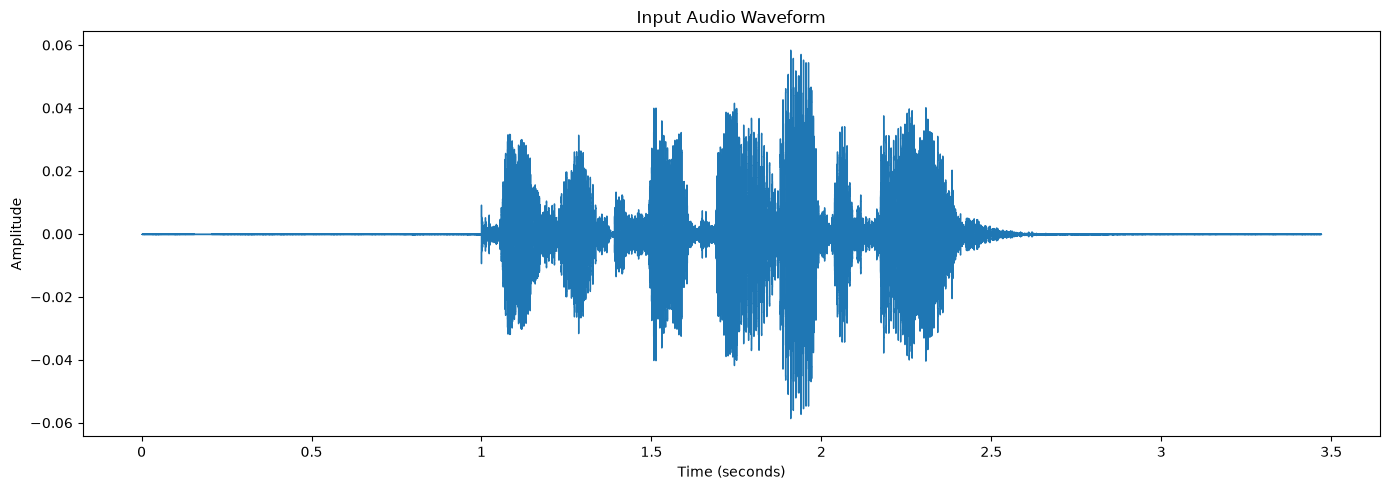

In [12]:
plt.figure(figsize=(14, 5))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title(
    "Input Audio Waveform"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Amplitude"
)

plt.tight_layout()

plt.show()

## 9. Input Audio MFCC Visualization

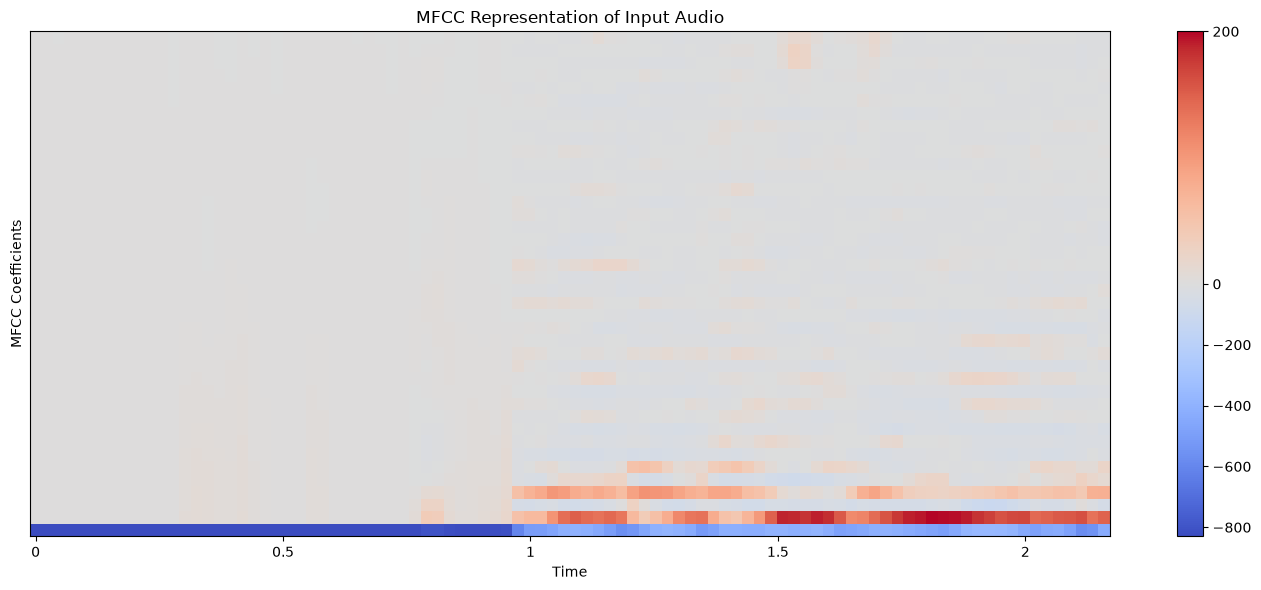

In [13]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title(
    "MFCC Representation of Input Audio"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "MFCC Coefficients"
)

plt.tight_layout()

plt.show()

## 10. Prepare Audio Features for CNN

The extracted MFCC feature has shape:

`(40, 94)`

The CNN expects:

`(1, 1, 40, 94)`

In [14]:
# Normalize MFCC
mfcc_normalized = (
    mfcc - mfcc.mean()
) / (
    mfcc.std() + 1e-8
)

# Add channel dimension
input_features = np.expand_dims(
    mfcc_normalized,
    axis=0
)

# Add batch dimension
input_features = np.expand_dims(
    input_features,
    axis=0
)

input_tensor = torch.tensor(
    input_features,
    dtype=torch.float32
).to(device)

print(
    "CNN Input Shape:",
    input_tensor.shape
)

CNN Input Shape: torch.Size([1, 1, 40, 94])


## 11. Predict Emotion



In [15]:
with torch.no_grad():

    output = model(
        input_tensor
    )

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_index = torch.argmax(
        probabilities,
        dim=1
    ).item()

    predicted_emotion = (
        class_names[predicted_index]
    )

    prediction_confidence = (
        probabilities[0, predicted_index]
        .item()
    )

print("=" * 50)
print("PREDICTION RESULT")
print("=" * 50)

print(
    "Predicted Emotion:",
    predicted_emotion.upper()
)

print(
    f"Confidence: "
    f"{prediction_confidence * 100:.2f}%"
)

PREDICTION RESULT
Predicted Emotion: HAPPY
Confidence: 35.88%


## 12. Prediction Probability for Every Emotion

In [16]:
probabilities_np = (
    probabilities[0]
    .cpu()
    .numpy()
)

for emotion, probability in zip(
    class_names,
    probabilities_np
):

    print(
        f"{emotion:10s} : "
        f"{probability * 100:.2f}%"
    )

angry      : 25.04%
calm       : 0.78%
disgust    : 15.56%
fearful    : 17.83%
happy      : 35.88%
neutral    : 1.65%
sad        : 1.97%
surprised  : 1.29%


## 13. Emotion Prediction Probabilities

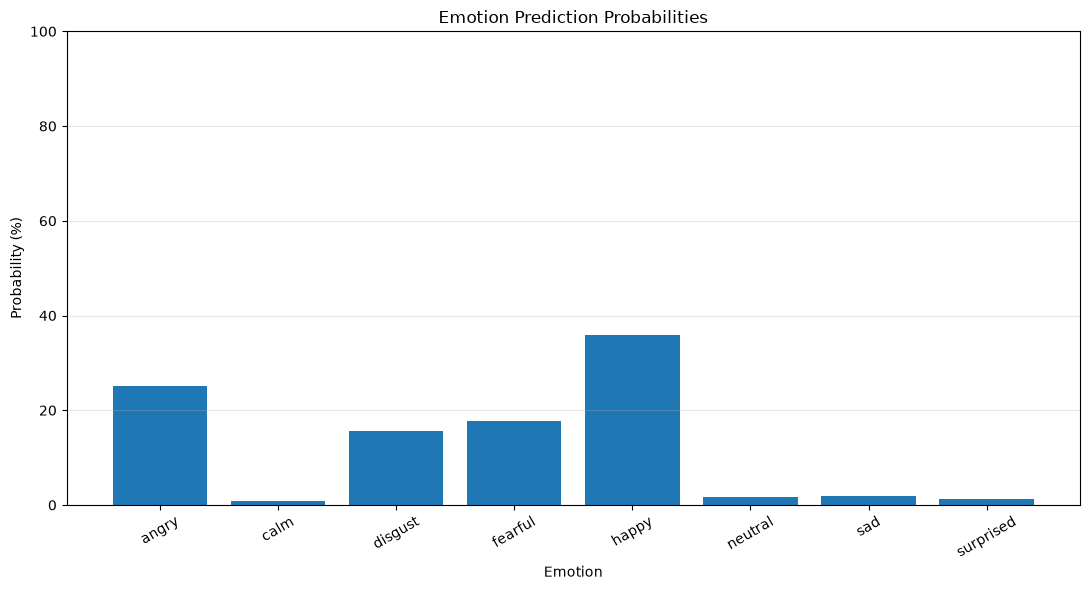

In [17]:
plt.figure(figsize=(11, 6))

plt.bar(
    class_names,
    probabilities_np * 100
)

plt.title(
    "Emotion Prediction Probabilities"
)

plt.xlabel(
    "Emotion"
)

plt.ylabel(
    "Probability (%)"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 14. Final Prediction Summary

In [18]:
print()
print("╔" + "═" * 48 + "╗")
print("║          SPEECH EMOTION PREDICTION          ║")
print("╠" + "═" * 48 + "╣")
print(
    f"║ Emotion    : "
    f"{predicted_emotion.upper():<30}║"
)
print(
    f"║ Confidence : "
    f"{prediction_confidence * 100:>7.2f}%"
    f"{' ' * 20}║"
)
print("╚" + "═" * 48 + "╝")


╔════════════════════════════════════════════════╗
║          SPEECH EMOTION PREDICTION          ║
╠════════════════════════════════════════════════╣
║ Emotion    : HAPPY                         ║
║ Confidence :   35.88%                    ║
╚════════════════════════════════════════════════╝


## 15. Save Prediction Result

In [19]:
prediction_result = {
    "audio_file": AUDIO_FILE,
    "predicted_emotion": predicted_emotion,
    "confidence": float(
        prediction_confidence
    ),
    "probabilities": {
        emotion: float(probability)
        for emotion, probability in zip(
            class_names,
            probabilities_np
        )
    }
}

os.makedirs(
    "../outputs",
    exist_ok=True
)

prediction_file = (
    "../outputs/latest_prediction.json"
)

with open(
    prediction_file,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        prediction_result,
        file,
        indent=4
    )

print(
    "✓ Prediction saved successfully"
)

print(
    prediction_file
)

✓ Prediction saved successfully
../outputs/latest_prediction.json


# Conclusion

The final Speech Emotion Recognition prediction pipeline
was successfully demonstrated using the trained CNN model.

A new audio file was processed through MFCC feature extraction,
normalized and passed to the trained CNN model.

The system successfully generates:

- Predicted emotion
- Prediction confidence
- Probability for each emotion
- Audio waveform visualization
- MFCC visualization
- Prediction probability graph

The trained model can now be used to classify new speech
audio samples into the supported emotion categories.

